<a href="https://colab.research.google.com/github/fcoliveira-utfpr/relacoes_fisicas_ambiente/blob/main/roteiros/aula_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 02 · Notebook auxiliar: figuras de radiação, temperatura e umidade

**Disciplina:** Relações Físicas do Ambiente Agrícola

Este notebook gera as cinco figuras usadas no roteiro da Aula 02:

| Figura | Arquivo | Dados |
|---|---|---|
| Qo ao longo do ano em diferentes latitudes | `aula02_qo_latitudes.png` | Apenas cálculo astronômico |
| Climatologia mensal do balanço de radiação | `aula02_climatologia_radiacao.png` | BR-DWGD no ponto |
| Amplitude térmica × transmissividade | `aula02_amplitude_transmissividade.png` | BR-DWGD no ponto |
| Boxplot da amplitude térmica mensal | `aula02_boxplot_amplitude.png` | BR-DWGD no ponto |
| Mapa de Qg média no Paraná | `aula02_mapa_qg_parana.png` | BR-DWGD em grade + `geobr` |

Todos os cálculos agrometeorológicos usam a biblioteca `agrometeorologiapy`.

# 1. Bibliotecas e autenticação
___

In [1]:
!pip install -q agrometeorologiapy geobr

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
import ee
import geobr
import agrometeorologiapy as amp

# ID do projeto do Google Cloud registrado no Earth Engine
ID_PROJETO = 'fcoliveira'

ee.Authenticate()
ee.Initialize(project=ID_PROJETO)
print('Earth Engine conectado ao projeto:', ID_PROJETO)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 50.6 MB/s eta 0:00:00


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine conectado ao projeto: fcoliveira


# 2. Configurações
___

Altere aqui o local, o período e as pastas de saída. Os anos são **inclusivos**.

In [2]:
# ================== LOCAL E PERÍODO (AJUSTÁVEIS) ==================
NOME_LOCAL = 'Santa Helena-PR'
LON, LAT   = -54.33, -24.86   # coordenadas do ponto (graus decimais)
ALTITUDE   = 258              # altitude do local (m), usada em Qg,cs
ANO_INICIO = 2001
ANO_FIM    = 2025
# ==================================================================

PERIODO = f'{ANO_INICIO}–{ANO_FIM}'

# Coleção diária do BR-DWGD (Xavier et al., 2022)
ASSET_XAVIER = 'projects/ee-alexandrexavier/assets/BR-DWGD'
BANDAS = ['Tmax', 'Tmin', 'Rs', 'RH']

# Fatores de escala e offset das bandas (valor real = bruto · escala + offset),
# conforme os exemplos oficiais do autor do conjunto de dados
ESCALA = {
    'Tmax': (0.00106815, 15.0),
    'Tmin': (0.00106815, 15.0),
    'Rs':   (0.15708661, -0.057087),
    'RH':   (0.39370079, -0.393701),
}

# Pastas de saída
PASTA_FIG = 'figuras'
PASTA_DADOS = 'dados'
os.makedirs(PASTA_FIG, exist_ok=True)
os.makedirs(PASTA_DADOS, exist_ok=True)

# Estilo padrão das figuras
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})
MESES = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
         'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']


def salvar(fig, nome):
    """Salva a figura em PNG (200 dpi) na pasta de figuras."""
    caminho = os.path.join(PASTA_FIG, nome)
    fig.savefig(caminho, dpi=200, bbox_inches='tight')
    print('Figura salva em:', caminho)

# 3. Figura 1: Qo ao longo do ano em diferentes latitudes
___

Cálculo puramente astronômico, sem dados de satélite. Para cada dia do ano (NDA), a sequência é:

δ → Hn → (d/D)² → Qo

Figura salva em: figuras/aula02_qo_latitudes.png


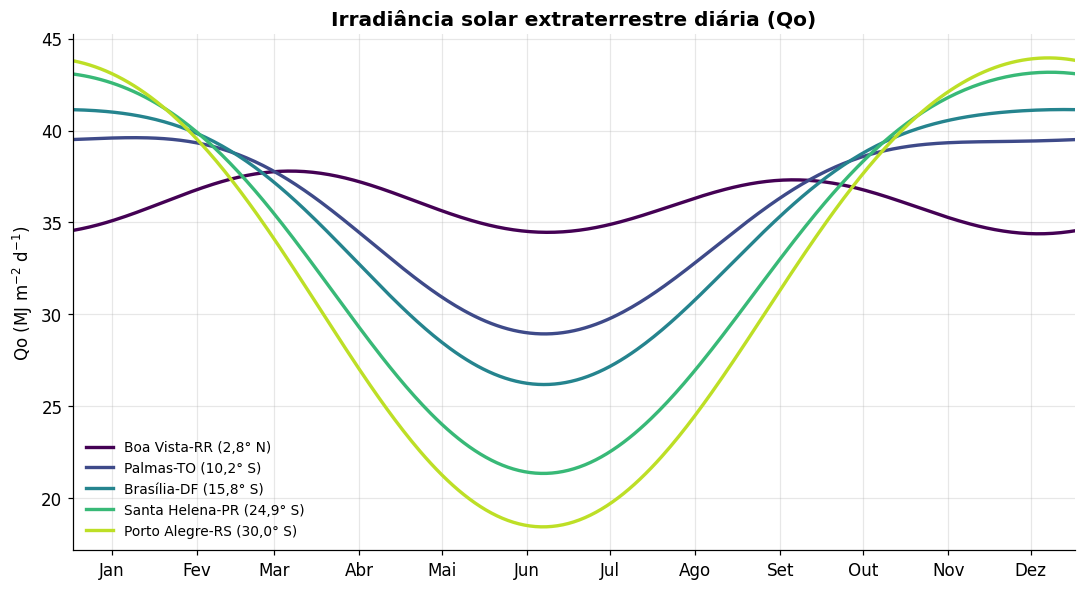

In [3]:
# Latitudes de referência, do extremo norte ao extremo sul do país
LOCAIS = {
    'Boa Vista-RR (2,8° N)':     2.82,
    'Palmas-TO (10,2° S)':     -10.18,
    'Brasília-DF (15,8° S)':   -15.78,
    'Santa Helena-PR (24,9° S)': -24.86,
    'Porto Alegre-RS (30,0° S)': -30.03,
}

NDA = np.arange(1, 366)                        # dias do ano
dec = amp.declinacao_solar(NDA)                # δ (graus)
dD2 = amp.fator_correcao_distancia(NDA)        # (d/D)²

cores = plt.cm.viridis(np.linspace(0, 0.9, len(LOCAIS)))
fig, ax = plt.subplots(figsize=(10, 5.5))

for (nome, lat), cor in zip(LOCAIS.items(), cores):
    Hn = amp.angulo_horario_nascer(lat, dec)
    Qo = amp.irradiancia_extraterrestre(lat, dec, Hn, dD2)
    ax.plot(NDA, Qo, color=cor, lw=2.2, label=nome)

# Eixo x com os meses (posição do dia 15 de cada mês)
ax.set_xticks([amp.nda(15, m) for m in range(1, 13)])
ax.set_xticklabels(MESES)
ax.set_xlim(1, 365)
ax.set_ylabel('Qo (MJ m$^{-2}$ d$^{-1}$)')
ax.set_title('Irradiância solar extraterrestre diária (Qo)', fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=9, loc='lower left', ncol=1)

plt.tight_layout()
salvar(fig, 'aula02_qo_latitudes.png')
plt.show()

# 4. Extração da série diária do BR-DWGD no ponto
___

A extração é feita **ano a ano**, porque pedir a série inteira de uma vez ultrapassa o limite de elementos do Earth Engine. Os valores brutos são convertidos com os fatores de escala e offset.

A base é salva em `dados/`. Se o arquivo já existir, o notebook apenas o lê, sem repetir a extração.

In [4]:
ARQ_BASE = os.path.join(PASTA_DADOS, f'xavier_{LON}_{LAT}_{ANO_INICIO}_{ANO_FIM}.csv')
ponto = ee.Geometry.Point([LON, LAT])


def extrair_ano(ano):
    """Extrai um ano de dados diários do BR-DWGD no ponto."""
    col = (ee.ImageCollection(ASSET_XAVIER)
           .filterDate(f'{ano}-01-01', f'{ano + 1}-01-01')
           .select(BANDAS))
    dados = col.getRegion(ponto, scale=10000).getInfo()
    tab = pd.DataFrame(dados[1:], columns=dados[0])
    # O identificador de cada imagem termina com a data (AAAAMMDD)
    tab['data'] = pd.to_datetime(tab['id'].str[-8:], format='%Y%m%d')
    return tab[['data'] + BANDAS]


if os.path.exists(ARQ_BASE):
    df = pd.read_csv(ARQ_BASE, parse_dates=['data'], index_col='data')
    print('Base lida do arquivo:', ARQ_BASE)
else:
    partes = []
    for ano in range(ANO_INICIO, ANO_FIM + 1):
        partes.append(extrair_ano(ano))
        print(f'{ano} ✔', end='  ')
    df = pd.concat(partes).set_index('data').sort_index()

    # Conversão dos valores brutos para unidades físicas.
    # Proteção: se os dados já vierem escalonados (Tmax < 100), não reescalona
    if df['Tmax'].abs().max() > 100:
        for banda, (mult, soma) in ESCALA.items():
            df[banda] = df[banda] * mult + soma
    else:
        print('\nAviso: os dados parecem já estar em unidades físicas; escala não aplicada.')

    df = df.rename(columns={'Rs': 'Qg', 'RH': 'UR'})
    df.to_csv(ARQ_BASE)
    print('\nBase salva em:', ARQ_BASE)

print(f'{len(df)} dias de {df.index.min():%d/%m/%Y} a {df.index.max():%d/%m/%Y}')
df.describe().round(2)

2001 ✔  2002 ✔  2003 ✔  2004 ✔  2005 ✔  2006 ✔  2007 ✔  2008 ✔  2009 ✔  2010 ✔  2011 ✔  2012 ✔  2013 ✔  2014 ✔  2015 ✔  2016 ✔  2017 ✔  2018 ✔  2019 ✔  2020 ✔  2021 ✔  2022 ✔  2023 ✔  2024 ✔  2025 ✔  
Base salva em: dados/xavier_-54.33_-24.86_2001_2025.csv
9131 dias de 01/01/2001 a 31/12/2025


,Tmax,Tmin,Qg,UR
count,9131.00,9131.00,9131.00,9131.00
mean,29.46,17.91,17.42,72.76
std,4.83,4.30,6.77,11.81
min,10.27,-0.64,1.20,30.71
25%,26.72,15.68,12.98,64.57
50%,30.22,18.79,17.22,73.62
75%,32.96,21.18,22.41,81.50
max,40.52,25.72,32.93,98.03


# 5. Variáveis astronômicas, controle de qualidade e balanço de radiação
___

Sequência de cálculo para cada dia:

1. **Astronômicas:** NDA, δ, Hn, N, (d/D)² e Qo.
2. **Controle de qualidade:** remove dias com falha, com Tmin > Tmax ou com Qg > Qo.
3. **Umidade:** es (Tetens, média dos extremos), ea e Δe.
4. **Balanço de radiação:** Qg,cs, BOC, BOL e Rn.

Na FAO-56, a razão Qg/Qg,cs é limitada a 1 no cálculo do BOL, pois valores acima disso não têm sentido físico e costumam vir de erros de interpolação.

In [5]:
# ---------- 1. Variáveis astronômicas ----------
df['NDA'] = df.index.dayofyear
df['dec'] = amp.declinacao_solar(df['NDA'])
df['Hn']  = amp.angulo_horario_nascer(LAT, df['dec'])
df['N']   = amp.fotoperiodo(df['Hn'])
df['dD2'] = amp.fator_correcao_distancia(df['NDA'])
df['Qo']  = amp.irradiancia_extraterrestre(LAT, df['dec'], df['Hn'], df['dD2'])

# ---------- 2. Controle de qualidade ----------
n0 = len(df)
falhas   = df[['Tmax', 'Tmin', 'Qg', 'UR']].isna().any(axis=1)
inv_temp = df['Tmin'] > df['Tmax']
inv_rad  = df['Qg'] > df['Qo']
df = df[~(falhas | inv_temp | inv_rad)].copy()

print(f'Dias com falha:      {falhas.sum()}')
print(f'Dias com Tmin > Tmax: {inv_temp.sum()}')
print(f'Dias com Qg > Qo:    {inv_rad.sum()}')
print(f'Dias removidos:      {n0 - len(df)} de {n0}')

# ---------- 3. Umidade ----------
df['es'] = (amp.es_tetens(df['Tmax']) + amp.es_tetens(df['Tmin'])) / 2
df['ea'] = amp.ea_umidade(df['es'], df['UR'])
df['De'] = amp.deficit_saturacao(df['es'], df['ea'])

# ---------- 4. Balanço de radiação ----------
df['Qg_cs'] = (0.75 + 2e-5 * ALTITUDE) * df['Qo']
Qg_lim = np.minimum(df['Qg'], df['Qg_cs'])        # limita Qg/Qg,cs a 1 (FAO-56)

df['BOC'] = amp.boc_saldo(df['Qg'])
df['BOL'] = amp.bol_saldo(df['Tmax'], df['Tmin'], df['ea'], Qg_lim, df['Qg_cs'])
df['Rn']  = amp.saldo_radiacao(df['BOC'], df['BOL'])

# Variáveis auxiliares para as figuras
df['DT']  = df['Tmax'] - df['Tmin']               # amplitude térmica
df['tau'] = df['Qg'] / df['Qo']                   # transmissividade
df['mes'] = df.index.month

df[['Qo', 'Qg', 'BOC', 'BOL', 'Rn', 'DT', 'tau']].describe().round(2)

Dias com falha:      0
Dias com Tmin > Tmax: 0
Dias com Qg > Qo:    0
Dias removidos:      0 de 9131


,Qo,Qg,BOC,BOL,Rn,DT,tau
count,9131.00,9131.00,9131.00,9131.00,9131.00,9131.00,9131.00
mean,33.18,17.42,13.06,-2.97,10.10,11.55,0.52
std,7.81,6.77,5.08,1.69,4.18,3.34,0.16
min,21.34,1.20,0.90,-7.11,2.16,1.45,0.05
25%,25.38,12.98,9.74,-4.29,6.48,9.43,0.42
50%,34.14,17.22,12.92,-3.12,9.70,11.87,0.57
75%,41.02,22.41,16.80,-1.74,13.53,13.89,0.66
max,43.17,32.93,24.70,1.42,19.19,23.28,0.80


# 6. Figura 2: climatologia mensal do balanço de radiação
___

Média mensal dos valores diários de Qo, Qg, BOC, BOL e Rn. É o formato do gráfico pedido na Etapa 2 do Projeto 1.

Figura salva em: figuras/aula02_climatologia_radiacao.png


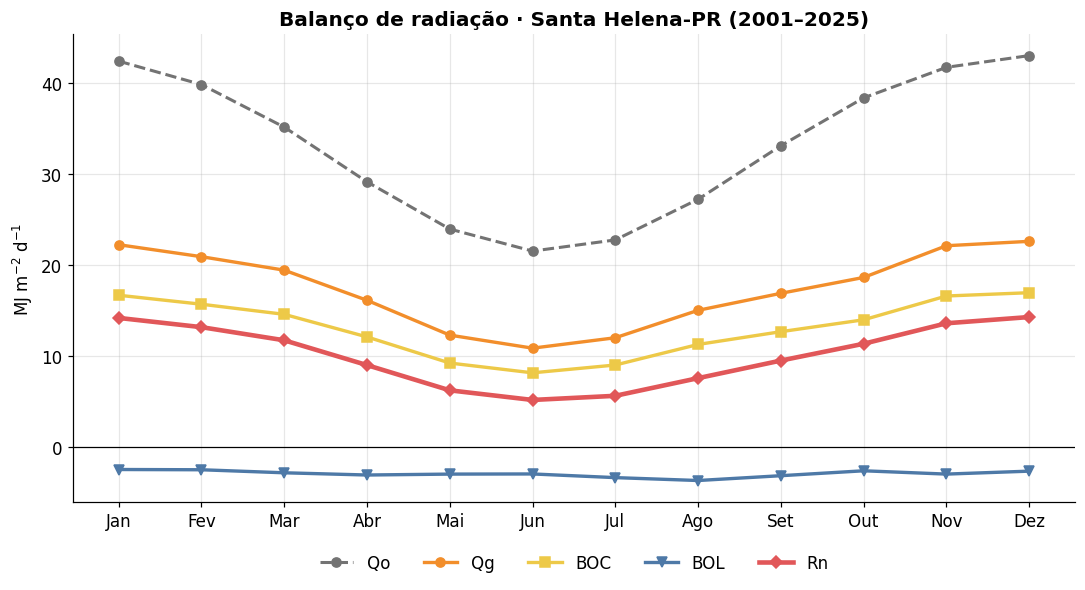

,Qo,Qg,BOC,BOL,Rn
mes,,,,,
1,42.45,22.24,16.68,-2.50,14.19
2,39.87,20.93,15.69,-2.53,13.17
3,35.19,19.44,14.58,-2.86,11.72
4,29.17,16.13,12.10,-3.10,8.99
5,23.97,12.29,9.22,-3.00,6.22
6,21.54,10.86,8.14,-2.99,5.16
7,22.77,12.01,9.00,-3.39,5.61
8,27.24,15.02,11.27,-3.71,7.56
9,33.14,16.90,12.67,-3.18,9.49


In [6]:
clima = df.groupby('mes')[['Qo', 'Qg', 'BOC', 'BOL', 'Rn']].mean()

estilo = {
    'Qo':  dict(color='0.45', ls='--', lw=2,   marker='o', label='Qo'),
    'Qg':  dict(color='#f28e2b', lw=2.2,       marker='o', label='Qg'),
    'BOC': dict(color='#edc948', lw=2.2,       marker='s', label='BOC'),
    'BOL': dict(color='#4e79a7', lw=2.2,       marker='v', label='BOL'),
    'Rn':  dict(color='#e15759', lw=3,         marker='D', label='Rn'),
}

fig, ax = plt.subplots(figsize=(10, 5.5))
for var, kw in estilo.items():
    ax.plot(clima.index, clima[var], ms=6, **kw)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES)
ax.set_ylabel('MJ m$^{-2}$ d$^{-1}$')
ax.set_title(f'Balanço de radiação · {NOME_LOCAL} ({PERIODO})', fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(frameon=False, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
salvar(fig, 'aula02_climatologia_radiacao.png')
plt.show()

clima.round(2)

# 7. Figura 3: amplitude térmica × transmissividade
___

Cada ponto é um dia. A curva de Hargreaves (Qg/Qo = k · ΔT⁰·⁵, com k = 0,16) mostra a ideia central dos modelos de Fernandes et al. (2018). As cores separam o semestre frio (abril a setembro) do semestre quente (outubro a março).

Figura salva em: figuras/aula02_amplitude_transmissividade.png


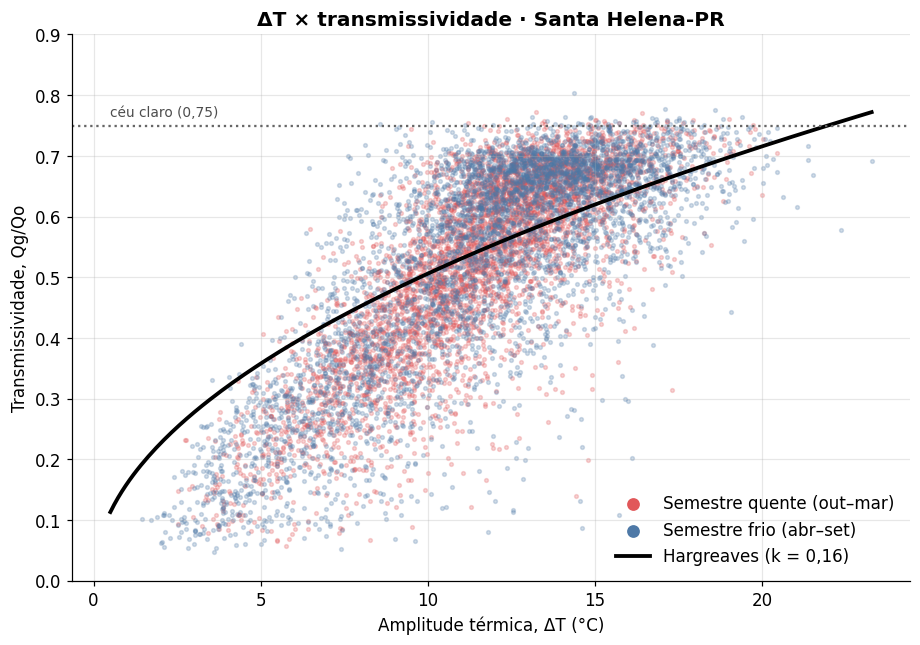

Correlação entre ΔT e Qg/Qo: r = 0.79


In [7]:
frio = df['mes'].between(4, 9)

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(df.loc[~frio, 'DT'], df.loc[~frio, 'tau'], s=6, alpha=0.25,
           color='#e15759', label='Semestre quente (out–mar)')
ax.scatter(df.loc[frio, 'DT'], df.loc[frio, 'tau'], s=6, alpha=0.25,
           color='#4e79a7', label='Semestre frio (abr–set)')

# Curva de Hargreaves com o k da biblioteca
dt = np.linspace(0.5, df['DT'].max(), 200)
ax.plot(dt, 0.16 * dt ** 0.5, color='black', lw=2.5,
        label='Hargreaves (k = 0,16)')

# Limite de céu claro
ax.axhline(0.75, color='0.4', ls=':', lw=1.5)
ax.text(0.5, 0.765, 'céu claro (0,75)', color='0.3', fontsize=9)

ax.set_xlabel('Amplitude térmica, ΔT (°C)')
ax.set_ylabel('Transmissividade, Qg/Qo')
ax.set_ylim(0, 0.9)
ax.set_title(f'ΔT × transmissividade · {NOME_LOCAL}', fontweight='bold')
ax.grid(alpha=0.3)
leg = ax.legend(frameon=False, loc='lower right', markerscale=3)
for h in leg.legend_handles[:2]:
    h.set_alpha(1)

plt.tight_layout()
salvar(fig, 'aula02_amplitude_transmissividade.png')
plt.show()

print(f'Correlação entre ΔT e Qg/Qo: r = {df["DT"].corr(df["tau"]):.2f}')

# 8. Figura 4: boxplot da amplitude térmica mensal
___

Equivalente à Fig. 2 de Fernandes et al. (2018).

Figura salva em: figuras/aula02_boxplot_amplitude.png


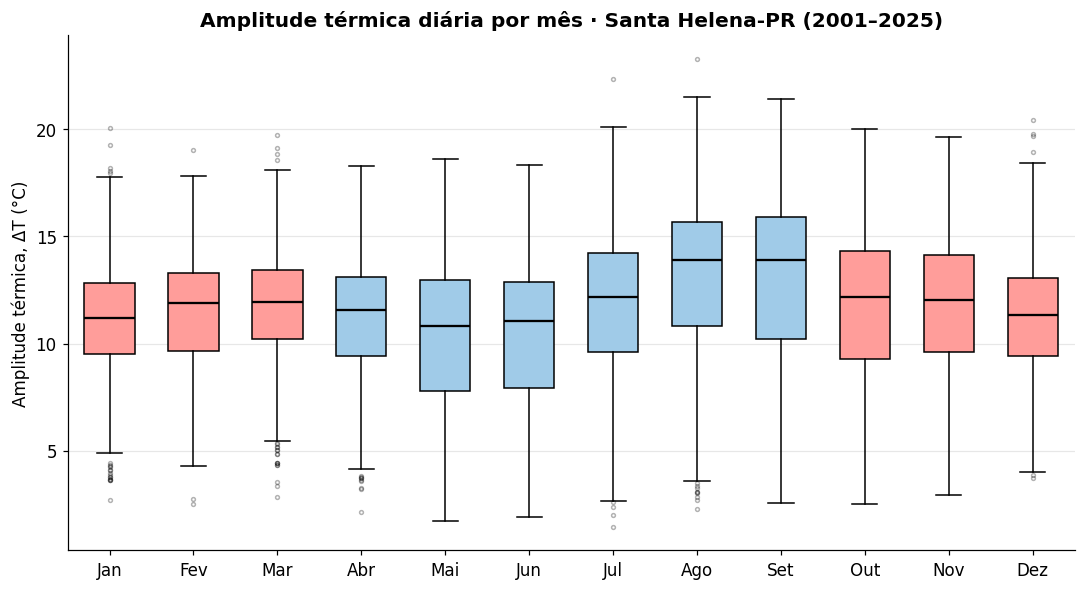

,mean,50%,std
mes,,,
1,11.1,11.2,2.7
2,11.5,11.9,2.6
3,11.7,11.9,2.7
4,11.2,11.6,2.9
5,10.4,10.8,3.5
6,10.3,11.1,3.4
7,11.7,12.2,3.6
8,13.0,13.9,3.7
9,13.1,13.9,3.9


In [8]:
dados_mes = [df.loc[df['mes'] == m, 'DT'].values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(10, 5.5))
bp = ax.boxplot(dados_mes, patch_artist=True, widths=0.6,
                medianprops=dict(color='black', lw=1.5),
                flierprops=dict(marker='o', ms=2.5, alpha=0.3))

# Cores: azul no semestre frio, vermelho no semestre quente
for m, caixa in enumerate(bp['boxes'], start=1):
    caixa.set_facecolor('#a0cbe8' if 4 <= m <= 9 else '#ff9d9a')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MESES)
ax.set_ylabel('Amplitude térmica, ΔT (°C)')
ax.set_title(f'Amplitude térmica diária por mês · {NOME_LOCAL} ({PERIODO})',
             fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
salvar(fig, 'aula02_boxplot_amplitude.png')
plt.show()

df.groupby('mes')['DT'].describe()[['mean', '50%', 'std']].round(1)

# 9. Figura 5: mapa de Qg média no Paraná
___

A média diária de Qg do período é calculada no Earth Engine e trazida como matriz NumPy (`ee.data.computePixels`). Os limites do estado e dos municípios vêm do pacote `geobr` (IBGE).

A reamostragem bilinear, aplicada imagem a imagem antes da média, apenas suaviza a visualização: a resolução real dos dados continua sendo 0,1°.

In [9]:
# ---------- Limites do IBGE via geobr ----------
uf = geobr.read_state(code_state='PR', year=2020)
municipios = geobr.read_municipality(code_muni='PR', year=2020)
contorno = uf.geometry.union_all()

# Retângulo envolvente do estado, com pequena margem
xmin, ymin, xmax, ymax = contorno.bounds
margem, RES = 0.1, 0.02                       # RES: resolução da matriz (graus)
xmin, ymin, xmax, ymax = xmin - margem, ymin - margem, xmax + margem, ymax + margem
largura = int(np.ceil((xmax - xmin) / RES))
altura  = int(np.ceil((ymax - ymin) / RES))


# ---------- Média de Qg no Earth Engine ----------
def escalar_suavizar(img):
    mult, soma = ESCALA['Rs']
    return (img.multiply(mult).add(soma)
               .resample('bilinear')
               .copyProperties(img, img.propertyNames()))

qg_media = (ee.ImageCollection(ASSET_XAVIER)
            .filterDate(f'{ANO_INICIO}-01-01', f'{ANO_FIM + 1}-01-01')
            .select('Rs')
            .map(escalar_suavizar)
            .mean())

matriz = ee.data.computePixels({
    'expression': qg_media,
    'fileFormat': 'NUMPY_NDARRAY',
    'grid': {
        'dimensions': {'width': largura, 'height': altura},
        'affineTransform': {'scaleX': RES, 'shearX': 0, 'translateX': xmin,
                            'shearY': 0, 'scaleY': -RES, 'translateY': ymax},
        'crsCode': 'EPSG:4326',
    },
})
qg = matriz[matriz.dtype.names[0]].astype(float)
print('Matriz:', qg.shape)

states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 127MB/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

municipalities_2020_simplified.parquet: 100%|██████████| 20.2M/20.2M [00:00<00:00, 133MB/s]


Matriz: (221, 340)


Figura salva em: figuras/aula02_mapa_qg_parana.png


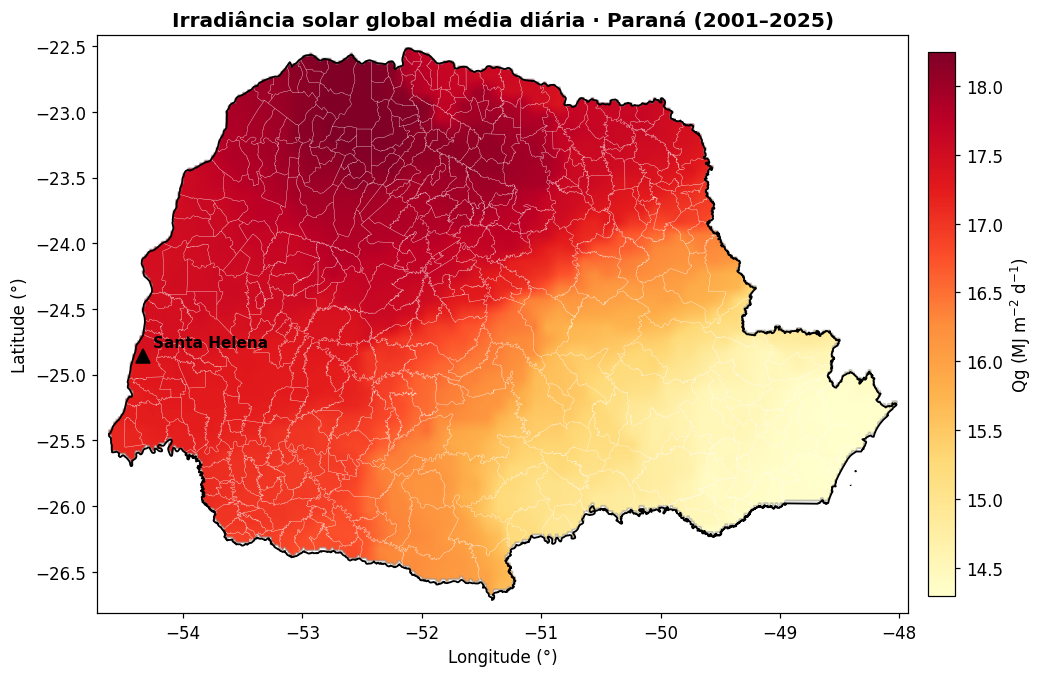

Qg média no estado: 16.7 (mín. 14.1, máx. 18.3) MJ m⁻² d⁻¹


In [10]:
def mascara_poligono(geom, xmin, ymax, res, forma):
    """Retorna máscara booleana (True dentro do polígono) para a grade."""
    poligonos = list(geom.geoms) if geom.geom_type == 'MultiPolygon' else [geom]
    lin, col = np.mgrid[0:forma[0], 0:forma[1]]
    centros = np.column_stack([(xmin + (col + 0.5) * res).ravel(),
                               (ymax - (lin + 0.5) * res).ravel()])
    dentro = np.zeros(len(centros), dtype=bool)
    for p in poligonos:
        dentro |= Path(np.asarray(p.exterior.coords)).contains_points(centros)
    return dentro.reshape(forma)


def mapa_parana(valores, titulo, unidade, cmap, arquivo):
    """Mapa da matriz recortada pelo contorno do Paraná, com municípios."""
    dentro = mascara_poligono(contorno, xmin, ymax, RES, valores.shape)
    v = np.where(dentro & (valores > 0), valores, np.nan)
    vmin, vmax = np.nanpercentile(v, [1, 99])

    fig, ax = plt.subplots(figsize=(10, 7))
    im = ax.imshow(v, extent=[xmin, xmax, ymin, ymax], origin='upper',
                   cmap=cmap, vmin=vmin, vmax=vmax, interpolation='bilinear')
    municipios.boundary.plot(ax=ax, color='white', lw=0.2, alpha=0.6)
    uf.boundary.plot(ax=ax, color='black', lw=1.2)

    ax.plot(LON, LAT, marker='^', color='black', ms=9)
    ax.annotate(NOME_LOCAL.split('-')[0], (LON, LAT), xytext=(6, 6),
                textcoords='offset points', fontsize=10, fontweight='bold')

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')
    ax.set_title(titulo, fontweight='bold')
    for lado in ['top', 'right']:
        ax.spines[lado].set_visible(True)

    cb = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
    cb.set_label(unidade)

    plt.tight_layout()
    salvar(fig, arquivo)
    plt.show()
    print(f'Qg média no estado: {np.nanmean(v):.1f} '
          f'(mín. {np.nanmin(v):.1f}, máx. {np.nanmax(v):.1f}) MJ m⁻² d⁻¹')


mapa_parana(qg, f'Irradiância solar global média diária · Paraná ({PERIODO})',
            'Qg (MJ m$^{-2}$ d$^{-1}$)', 'YlOrRd', 'aula02_mapa_qg_parana.png')

# 10. Referências
___

XAVIER, A. C.; SCANLON, B. R.; KING, C. W.; ALVES, A. I. New improved Brazilian daily weather gridded data (1961–2020). **International Journal of Climatology**, v. 42, n. 16, p. 8390-8404, 2022. DOI: 10.1002/joc.7731.

PEREIRA, R. H. M.; GONÇALVES, C. N. et al. **geobr**: loads shapefiles of official spatial data sets of Brazil. GitHub repository, 2019. https://github.com/ipeaGIT/geobr.